In [4]:
%%capture
!git clone https://github.com/iabufarha/ArSarcasm-v2.git

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

training = pd.read_csv('ArSarcasm-v2/ArSarcasm-v2/training_data.csv')
testing = pd.read_csv('ArSarcasm-v2/ArSarcasm-v2/testing_data.csv')

data = pd.concat([training, testing], ignore_index=True)

data = data.groupby(['sarcasm', 'sentiment', 'dialect']).size().reset_index(name='count')
data = data.sort_values(by='count', ascending=False)

def plot_bar_graphs(data):
    # Plot original counts
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(data)), data['count'], color='blue', alpha=0.7, label='Original Count')
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.title('Distribution of Original Labels')

    # Set x-axis ticks and labels
    plt.xticks(range(len(data)), data.apply(lambda x: f"{x['sarcasm']}, {x['sentiment']}, {x['dialect']}", axis=1), rotation=90)

    # Add numbers on top of bars at 45 degrees
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', ha='center', va='bottom', rotation=45)

    plt.legend()
    plt.tight_layout()
    plt.show()

    # Set x-axis ticks and labels
    plt.xticks(range(len(data)), data.apply(lambda x: f"{x['sarcasm']}, {x['sentiment']}, {x['dialect']}", axis=1), rotation=90)

    # Add numbers on top of bars at 45 degrees
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', ha='center', va='bottom', rotation=45)

    plt.legend()
    plt.tight_layout()
    plt.show()

# Call the function to plot bar graphs
plot_bar_graphs(data)


Output hidden; open in https://colab.research.google.com to view.

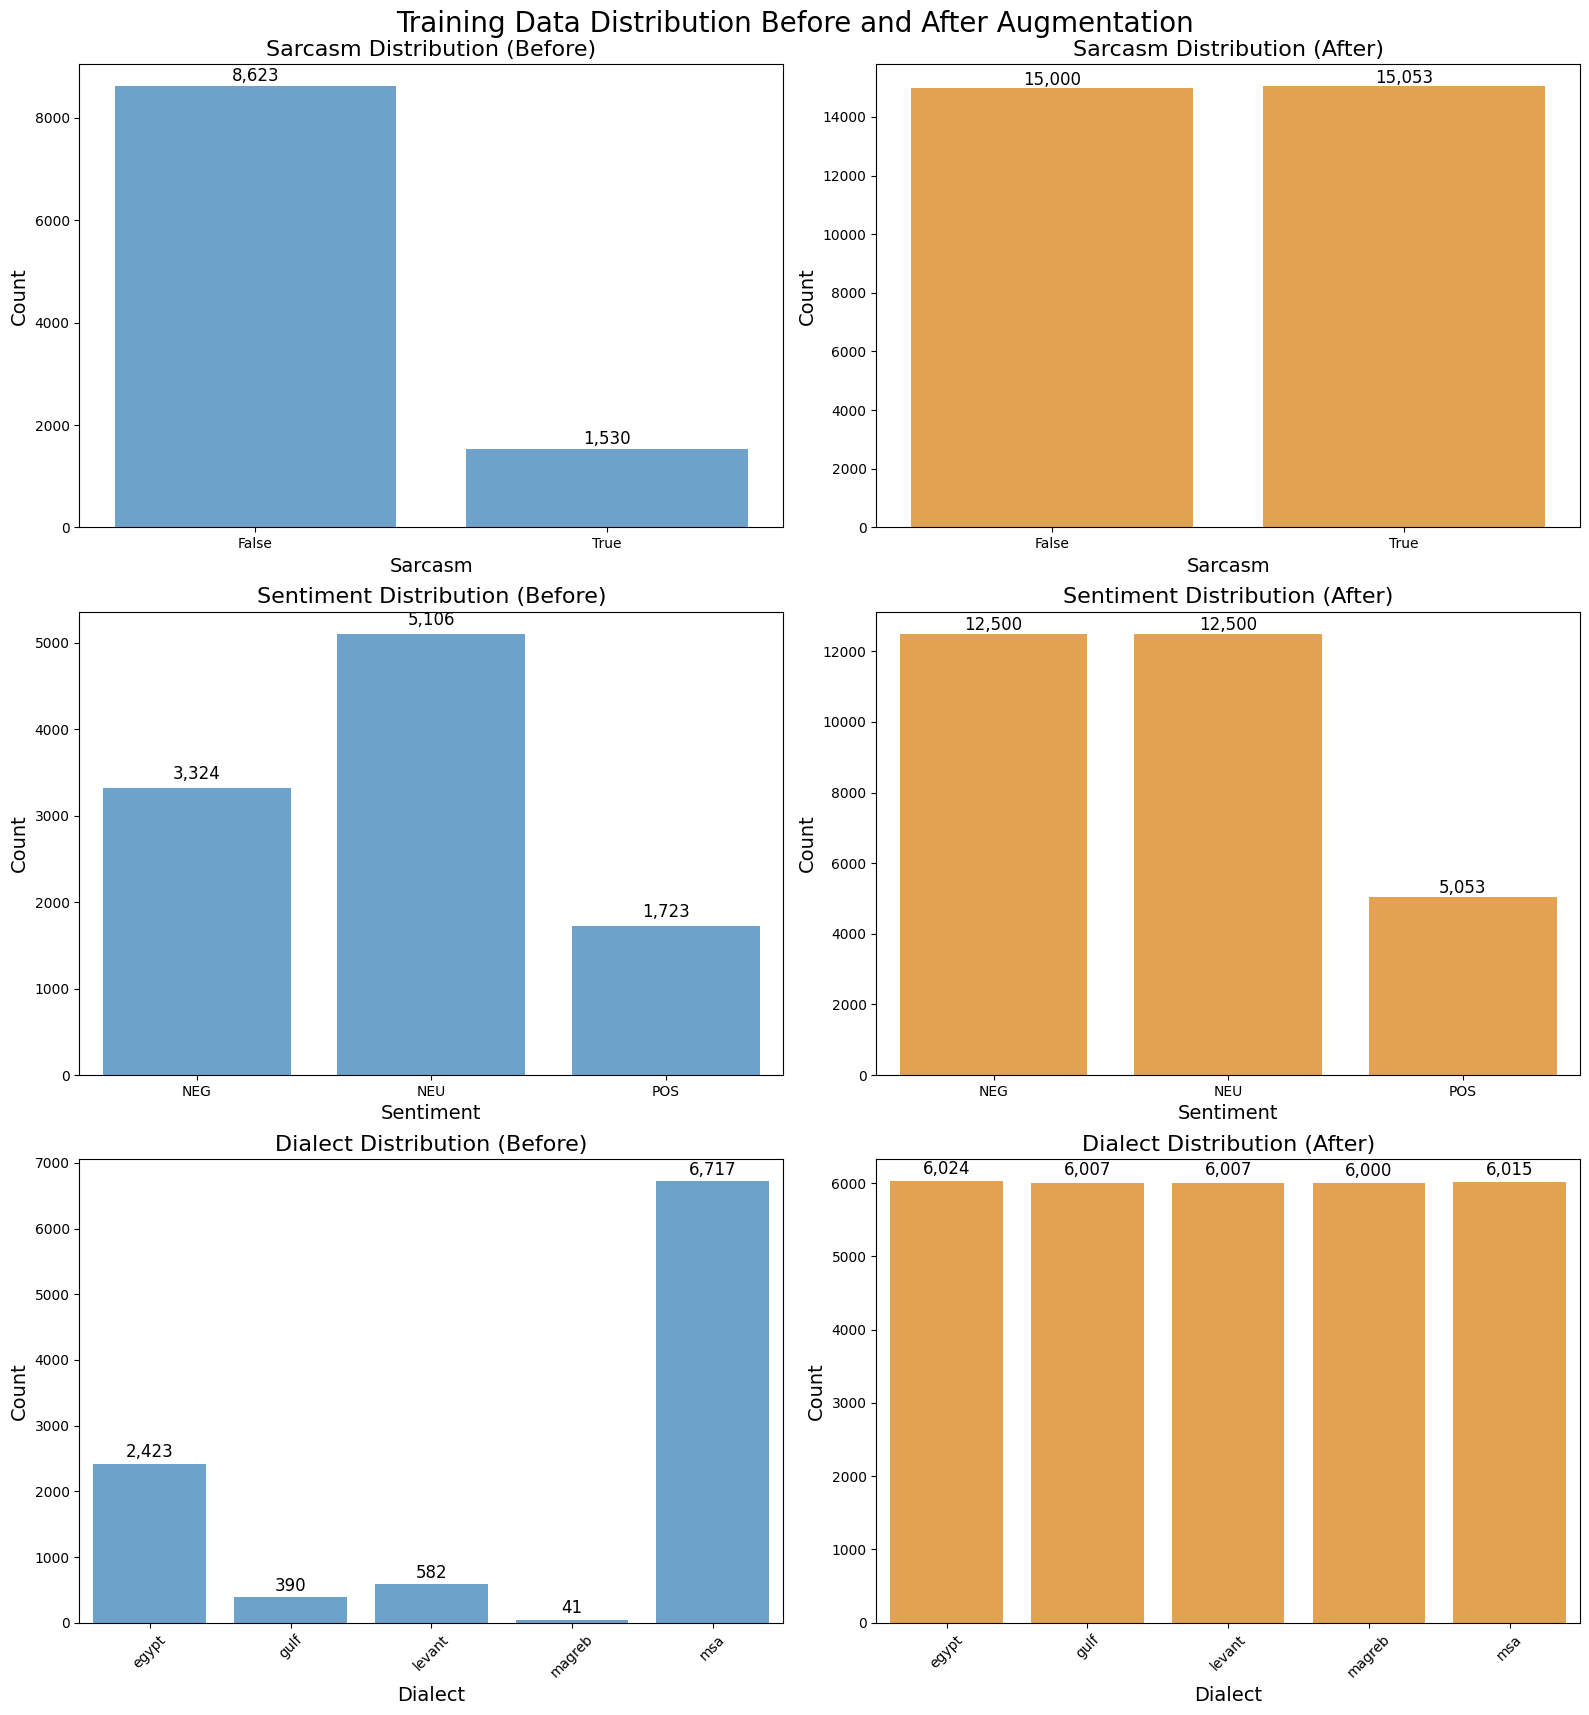

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrames from your logs
# Original dataset
original_sarcasm = pd.DataFrame({
    'sarcasm': ['False', 'True'],
    'count': [8623, 1530]
})

original_sentiment = pd.DataFrame({
    'sentiment': ['NEG', 'NEU', 'POS'],
    'count': [3324, 5106, 1723]
})

original_dialect = pd.DataFrame({
    'dialect': ['egypt', 'gulf', 'levant', 'magreb', 'msa'],
    'count': [2423, 390, 582, 41, 6717]
})

# Final dataset after augmentation
final_sarcasm = pd.DataFrame({
    'sarcasm': ['False', 'True'],
    'count': [15000, 15053]
})

final_sentiment = pd.DataFrame({
    'sentiment': ['NEG', 'NEU', 'POS'],
    'count': [12500, 12500, 5053]
})

final_dialect = pd.DataFrame({
    'dialect': ['egypt', 'gulf', 'levant', 'magreb', 'msa'],
    'count': [6024, 6007, 6007, 6000, 6015]
})

# Set up the figure with 3 rows and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Training Data Distribution Before and After Augmentation', fontsize=20, y=0.95)

# Color palettes
before_color = '#5DA5DA'  # Light blue
after_color = '#FAA43A'   # Orange

# Plot sarcasm distribution
sns.barplot(x='sarcasm', y='count', data=original_sarcasm, ax=axes[0, 0], color=before_color)
axes[0, 0].set_title('Sarcasm Distribution (Before)', fontsize=16)
axes[0, 0].set_ylabel('Count', fontsize=14)
axes[0, 0].set_xlabel('Sarcasm', fontsize=14)
for i, v in enumerate(original_sarcasm['count']):
    axes[0, 0].text(i, v + 100, f"{v:,}", ha='center', fontsize=12)

sns.barplot(x='sarcasm', y='count', data=final_sarcasm, ax=axes[0, 1], color=after_color)
axes[0, 1].set_title('Sarcasm Distribution (After)', fontsize=16)
axes[0, 1].set_ylabel('Count', fontsize=14)
axes[0, 1].set_xlabel('Sarcasm', fontsize=14)
for i, v in enumerate(final_sarcasm['count']):
    axes[0, 1].text(i, v + 100, f"{v:,}", ha='center', fontsize=12)

# Plot sentiment distribution
sns.barplot(x='sentiment', y='count', data=original_sentiment, ax=axes[1, 0], color=before_color)
axes[1, 0].set_title('Sentiment Distribution (Before)', fontsize=16)
axes[1, 0].set_ylabel('Count', fontsize=14)
axes[1, 0].set_xlabel('Sentiment', fontsize=14)
for i, v in enumerate(original_sentiment['count']):
    axes[1, 0].text(i, v + 100, f"{v:,}", ha='center', fontsize=12)

sns.barplot(x='sentiment', y='count', data=final_sentiment, ax=axes[1, 1], color=after_color)
axes[1, 1].set_title('Sentiment Distribution (After)', fontsize=16)
axes[1, 1].set_ylabel('Count', fontsize=14)
axes[1, 1].set_xlabel('Sentiment', fontsize=14)
for i, v in enumerate(final_sentiment['count']):
    axes[1, 1].text(i, v + 100, f"{v:,}", ha='center', fontsize=12)

# Plot dialect distribution
sns.barplot(x='dialect', y='count', data=original_dialect, ax=axes[2, 0], color=before_color)
axes[2, 0].set_title('Dialect Distribution (Before)', fontsize=16)
axes[2, 0].set_ylabel('Count', fontsize=14)
axes[2, 0].set_xlabel('Dialect', fontsize=14)
axes[2, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(original_dialect['count']):
    axes[2, 0].text(i, v + 100, f"{v:,}", ha='center', fontsize=12)

sns.barplot(x='dialect', y='count', data=final_dialect, ax=axes[2, 1], color=after_color)
axes[2, 1].set_title('Dialect Distribution (After)', fontsize=16)
axes[2, 1].set_ylabel('Count', fontsize=14)
axes[2, 1].set_xlabel('Dialect', fontsize=14)
axes[2, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(final_dialect['count']):
    axes[2, 1].text(i, v + 100, f"{v:,}", ha='center', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig('dataset_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
